# Setup

In [2]:
# !pip install -U langchain langchain-community langchain-experimental langchain-core langchain_huggingface langchain-openai langsmith langchainhub pymupdf sentence-transformers faiss-cpu pypdf

## OpenAI Key 등록
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [OpenAI 요금](https://openai.com/api/pricing/)

In [ ]:
import os

os.environ['OPENAI_API_KEY'] = 'sk-'


# [Reranker](https://python.langchain.com/docs/integrations/retrievers/)
- Reranker(리랭커)는 현대적인 두 단계 검색 시스템(Two-Stage Retrieval System)에서 사용되는 핵심 컴포넌트입니다. 대규모 데이터셋에서 효율적이고 정확한 검색을 수행하기 위해 설계되었으며, 주로 첫 번째 단계인 Retriever가 찾아낸 문서들의 순위를 재조정하는 역할을 합니다.

## [Reranker가 필요한 이유](https://aws.amazon.com/ko/blogs/tech/korean-reranker-rag/)

먼저 현재 RAG의 문제점에 대해서 살펴보도록 하겠습니다. RAG는 수많은 텍스트 문서에서 의미론적 검색 (Semantic search) 과정을 수행합니다. 의미론적 검색에는 일반적으로 벡터 검색을 활용 되는데, 이 과정에서 두 가지 정보 손실이 발생하게 됩니다.
- `첫 번째는 문서의 임베딩 벡터 변환 과정에서의 손실입니다.` 임베딩 벡터 변환이란 문서를 n개의 숫자로 재 표현하는 것을 의미하는데, 정보의 손실은 문서가 긴 경우에 정해진 벡터의 차원으로 표현하기 어려울 때 발생하게 됩니다.
- `두 번째는 검색 과정에서의 손실입니다.` RAG는 검색 시간 단축을 위해 Approximate Nearnest Neighbor search (ANNs) 기술을 활용합니다. 이 방법은 질문과 문서 사이의 관련성 체크 횟수를 현저히 줄임으로써 검색속도를 높일 수 있습니다. 하지만 이 과정에서 발생하는 관련성 정확도 하락이 정보의 손실로 나타나게 됩니다. 이러한 정보 손실로 인해 LLM으로 전달되는 컨텍스트의 상위 k개 이내에서 질문에 대한 관련 정보가 누락되는 경우가 발생합니다.

- 이러한 문제는 검색 후 반환되는 문서수를 늘림 (k 증가) 으로써 간단히 해결할 수 있습니다. 하지만 이 방법은 LLM에 전달하는 컨텍스트가 늘어나기 때문에 비용 효율적이지 않습니다.
- 그 뿐만이 아닙니다. 최근 출판된 논문에 따르면 RAG의 정확도는 관련정보의 컨텍스트 내 존재 유무가 아닌, 순서라는 것을 발견하였습니다.

즉, 관련 정보가 컨텍스트 내 상위권에 위치하고 있을 때 좋은 답변을 얻을 수 있다는 뜻 입니다.

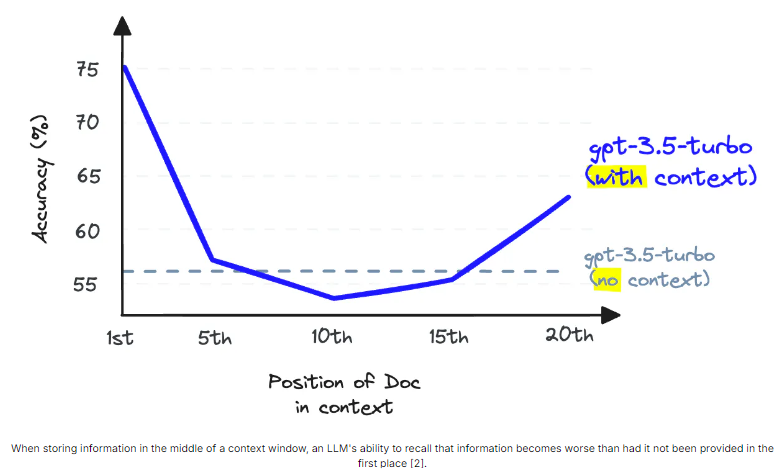

##[Power of Rerankers](https://www.pinecone.io/learn/series/rag/rerankers/)
- 기존에 벡터 검색을 위해 사용하는 구조가 `Bi-encoder`라면, `rerank`를 위한 구조는 `Cross-encoder`입니다.
- `Bi-encoder`는 질의와 정보를 각각 임베딩한 후 유사도를 계산합니다.
- `Cross-encoder`는 질의와 정보를 입력으로 사용하여 유사도를 출력합니다. 질의와 정보를 각각 입력하고 유사도를 얻는 `Bi-encoder`와 다르게 질의와 정보의 내용을 한번에 고려하기 때문에 더욱 정확한 유사도를 얻을 수 있다고 합니다. 이 유사도를 사용하여 질의와의 관련성에 따라 정보(문서)를 재정렬합니다.
- 하지만 `Cross-encoder`는 모든 조합들을 활용해 인풋으로 활용해야 하기 때문에, 비용이 높습니다. 때문에 일반적인 벡터 검색(`retrieval`)을 진행한 후, `reranker` 기반으로 순위를 재정렬하는 경우가 일반적입니다.


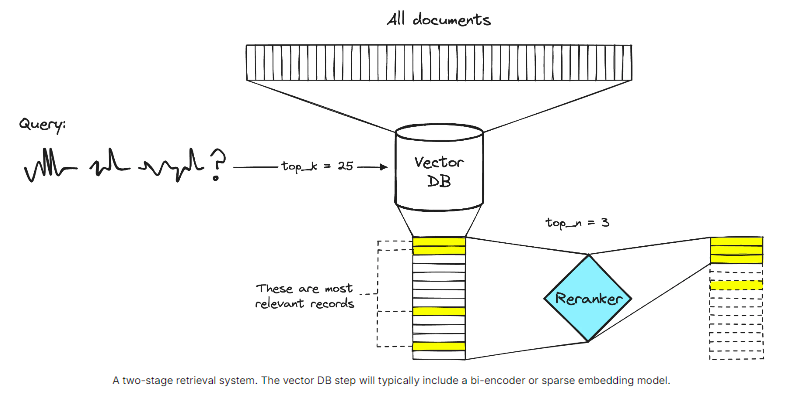

### Bi-encoder

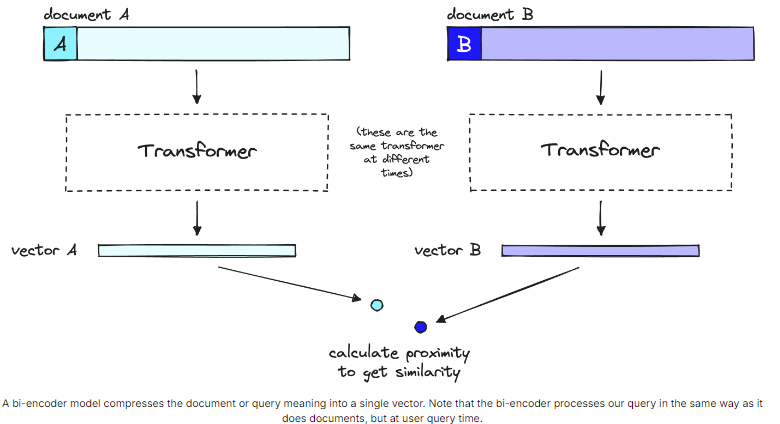

### Cross-encoder

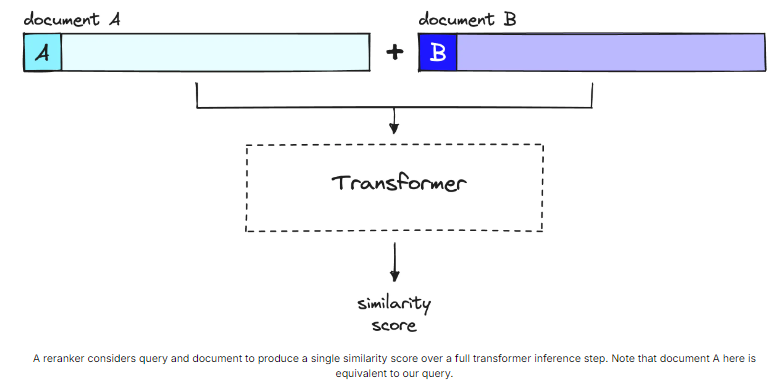

## Reranker 장단점

- 장점
  - 검색 정확도 크게 향상
  - 복잡한 의미적 관계 모델링 가능
  - 첫 단계 검색의 한계 보완
- 단점
  - 계산 비용 증가
  - 처리 시간 증가
  - 대규모 데이터셋에 직접 적용 어려움

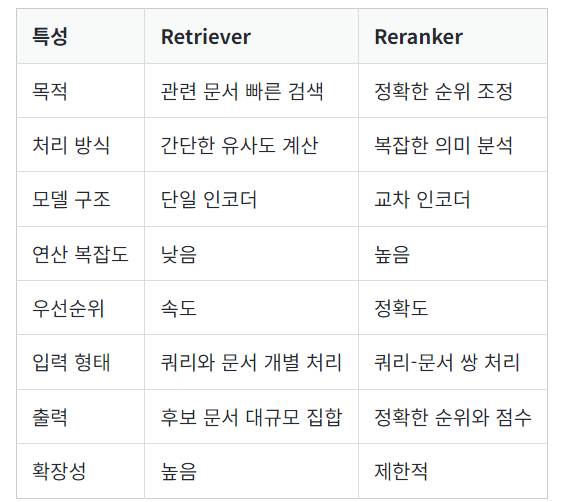

# Reranker 예제
- Cross encoder reranker는 검색 증강 생성(RAG) 시스템의 성능을 향상시키기 위해 사용되는 기술입니다. 이 문서는 Hugging Face의 cross encoder 모델을 사용하여 retriever에서 reranker를 구현하는 방법을 설명합니다.

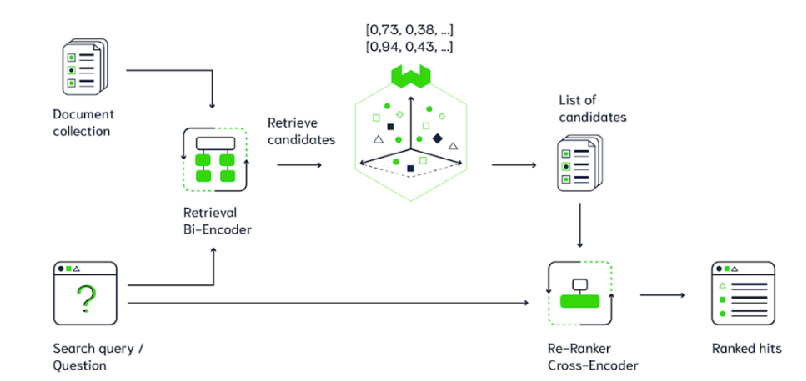

In [1]:
# 문서 출력 도우미 함수
def pretty_print_docs(docs):
    print(
        f"\n{'-' * 100}\n".join(
            [f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(docs)]
        )
    )

In [2]:
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

## Vector DB

- 문서 로드

In [3]:
# 문서 로드
DATA_PATH = "./data/"

documents = TextLoader(DATA_PATH+"rag-keywords.txt").load()

In [4]:
len(documents)

1

- 텍스트 분할기 설정

In [5]:
# 텍스트 분할기 설정
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

- 문서 분할

In [6]:
# 문서 분할
texts = text_splitter.split_documents(documents)

In [7]:
len(texts)

15

- 임베딩 모델 설정

In [8]:
# 임베딩 모델 설정
embeddingsModel = HuggingFaceEmbeddings(
    model_name="sentence-transformers/msmarco-distilbert-dot-v5",
    cache_folder="./models/",
    model_kwargs={"device": "cpu"}  # CPU 사용
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
embeddingsModel

HuggingFaceEmbeddings(model_name='sentence-transformers/msmarco-distilbert-dot-v5', cache_folder='./models/', model_kwargs={'device': 'cpu'}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

- 문서로부터 vectorstore 생성

In [11]:
vector_db = Chroma.from_documents(
    documents=texts, # 문서 리스트
    embedding=embeddingsModel, # 임베딩 함수
    collection_name="rag_keywords", # 컬렉션 이름
    persist_directory="./chroma_rag_keywords" # 영구 저장 경로
)

print("파일이 Chroma VectorStore에 저장되었습니다.")

파일이 Chroma VectorStore에 저장되었습니다.


## [Cross-Encoder](https://medium.com/@mauryaanoop3/the-indispensable-reranker-a-deep-dive-into-optimizing-retrieval-in-retrieval-augmented-generation-a12793ee393c)
- Bi-Encoder
  - Vector DB를 이용한 유사도 결과값
- Cross-Encoder
  - CrossEncoder을 이용한 LLM의 예측값

### Retriever

- 검색기 설정

In [12]:
# 검색기 설정
retriever = vector_db.as_retriever(
    search_kwargs={"k": 10}
)

- 질의 설정

In [13]:
# 질의 설정
query = "Word2Vec 에 대해서 알려줄래?"

- 질의 수행 및 결과 문서 반환

In [14]:
# 질의 수행 및 결과 문서 반환
docs = retriever.invoke(query)

In [15]:
len(docs)

10

- 결과 문서 출력

In [16]:
# 결과 문서 출력
pretty_print_docs(docs)

Document 1:

Open Source

정의: 오픈 소스는 소스 코드가 공개되어 누구나 자유롭게 사용, 수정, 배포할 수 있는 소프트웨어를 의미합니다. 이는 협업과 혁신을 촉진하는 데 중요한 역할을 합니다.
예시: 리눅스 운영 체제는 대표적인 오픈 소스 프로젝트입니다.
연관키워드: 소프트웨어 개발, 커뮤니티, 기술 협업

Structured Data

정의: 구조화된 데이터는 정해진 형식이나 스키마에 따라 조직된 데이터입니다. 이는 데이터베이스, 스프레드시트 등에서 쉽게 검색하고 분석할 수 있습니다.
예시: 관계형 데이터베이스에 저장된 고객 정보 테이블은 구조화된 데이터의 예입니다.
연관키워드: 데이터베이스, 데이터 분석, 데이터 모델링

Parser
----------------------------------------------------------------------------------------------------
Document 2:

Open Source

정의: 오픈 소스는 소스 코드가 공개되어 누구나 자유롭게 사용, 수정, 배포할 수 있는 소프트웨어를 의미합니다. 이는 협업과 혁신을 촉진하는 데 중요한 역할을 합니다.
예시: 리눅스 운영 체제는 대표적인 오픈 소스 프로젝트입니다.
연관키워드: 소프트웨어 개발, 커뮤니티, 기술 협업

Structured Data

정의: 구조화된 데이터는 정해진 형식이나 스키마에 따라 조직된 데이터입니다. 이는 데이터베이스, 스프레드시트 등에서 쉽게 검색하고 분석할 수 있습니다.
예시: 관계형 데이터베이스에 저장된 고객 정보 테이블은 구조화된 데이터의 예입니다.
연관키워드: 데이터베이스, 데이터 분석, 데이터 모델링

Parser
----------------------------------------------------------------------------------------------------
Document 3:

정의: LLM은 대규모의 텍스트 데이터로 훈련된 큰 규모의 언어 모델을

### CrossEncoder

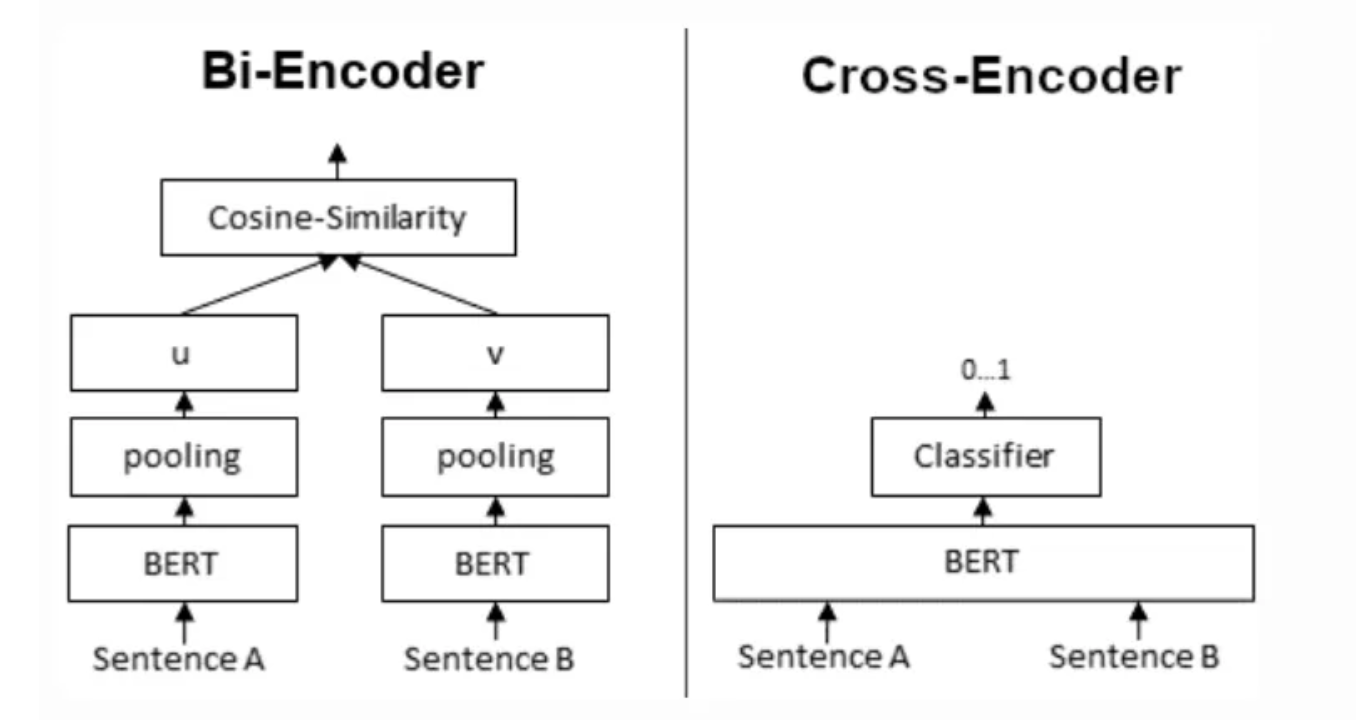

In [17]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder(
    "Dongjin-kr/ko-reranker", max_length = 512, device="cpu", cache_folder="./models/"
)

config.json:   0%|          | 0.00/802 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

### Run

In [18]:
reranked_docs = cross_encoder.rank(
    query, # 사용자 질의
    [doc.page_content for doc in docs], # Retriever의 결과값
    top_k=3,
    return_documents=True,
)

In [19]:
# 문서 출력
print(
    f"\n{'-' * 100}\n".join(
        [f"Document {i+1}:\n\n" + d["text"] for i, d in enumerate(reranked_docs)]
    )
)

Document 1:

Page Rank

정의: 페이지 랭크는 웹 페이지의 중요도를 평가하는 알고리즘으로, 주로 검색 엔진 결과의 순위를 결정하는 데 사용됩니다. 이는 웹 페이지 간의 링크 구조를 분석하여 평가합니다.
예시: 구글 검색 엔진은 페이지 랭크 알고리즘을 사용하여 검색 결과의 순위를 정합니다.
연관키워드: 검색 엔진 최적화, 웹 분석, 링크 분석

데이터 마이닝

정의: 데이터 마이닝은 대량의 데이터에서 유용한 정보를 발굴하는 과정입니다. 이는 통계, 머신러닝, 패턴 인식 등의 기술을 활용합니다.
예시: 소매업체가 고객 구매 데이터를 분석하여 판매 전략을 수립하는 것은 데이터 마이닝의 예입니다.
연관키워드: 빅데이터, 패턴 인식, 예측 분석

멀티모달 (Multimodal)
----------------------------------------------------------------------------------------------------
Document 2:

Page Rank

정의: 페이지 랭크는 웹 페이지의 중요도를 평가하는 알고리즘으로, 주로 검색 엔진 결과의 순위를 결정하는 데 사용됩니다. 이는 웹 페이지 간의 링크 구조를 분석하여 평가합니다.
예시: 구글 검색 엔진은 페이지 랭크 알고리즘을 사용하여 검색 결과의 순위를 정합니다.
연관키워드: 검색 엔진 최적화, 웹 분석, 링크 분석

데이터 마이닝

정의: 데이터 마이닝은 대량의 데이터에서 유용한 정보를 발굴하는 과정입니다. 이는 통계, 머신러닝, 패턴 인식 등의 기술을 활용합니다.
예시: 소매업체가 고객 구매 데이터를 분석하여 판매 전략을 수립하는 것은 데이터 마이닝의 예입니다.
연관키워드: 빅데이터, 패턴 인식, 예측 분석

멀티모달 (Multimodal)
----------------------------------------------------------------------------------------------------
Document 3:

Open So